Name: Navpreet Kloy

Monday Lab Partner: Oscar Ramos

Wednesday Lab Partner: Oscar Ramos



Credit card dataset: SVM Classification: https://www.kaggle.com/code/pierra/credit-card-dataset-svm-classification/input

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
# load dataset
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# data info overview
df.info()
# number of total samples and features
print('\n ',df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# view class distrubtion of fraud (1) and non-fraud (0)
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
df_fraud = df[df['Class'] == 1]
df_normal = df[df['Class'] == 0].sample(n=10000, random_state=42)

df_small = pd.concat([df_fraud, df_normal])

In [ ]:
# Select features and label
X = df_small.drop(['Class'], axis=1)
y = df_small['Class']



In [ ]:
# Split the data into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn scaling from training data
X_test_scaled = scaler.transform(X_test)        # Apply same scaling to test data

In [ ]:
# Create an SVM classifier with a linear kernel
svm_classifier = SVC(kernel='linear', C=1.0)

# Train the SVM model using the training data
svm_classifier.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = svm_classifier.predict(X_test_scaled)

In [ ]:
# Evaluate model

# Calculate the accuracy of our model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification Report for model
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

Accuracy: 99.14%

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       0.99      1.00      1.00      2001
       Fraud       1.00      0.82      0.90        98

    accuracy                           0.99      2099
   macro avg       1.00      0.91      0.95      2099
weighted avg       0.99      0.99      0.99      2099



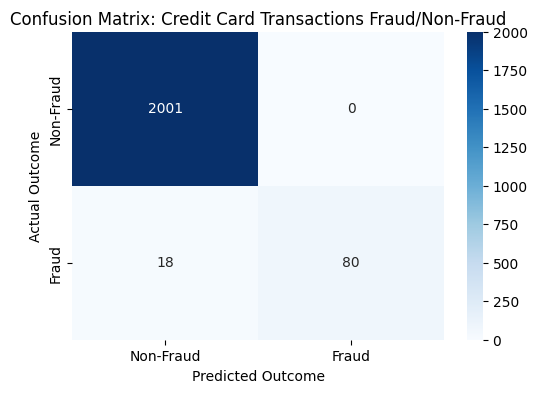

In [ ]:
# Confusion matrix  -- see credit card transactions are being predicted vs actual
cm = confusion_matrix(y_test, y_pred)

# define class labels for plot
labels = ['Non-Fraud', 'Fraud']

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.title('Confusion Matrix: Credit Card Transactions Fraud/Non-Fraud')
plt.show()


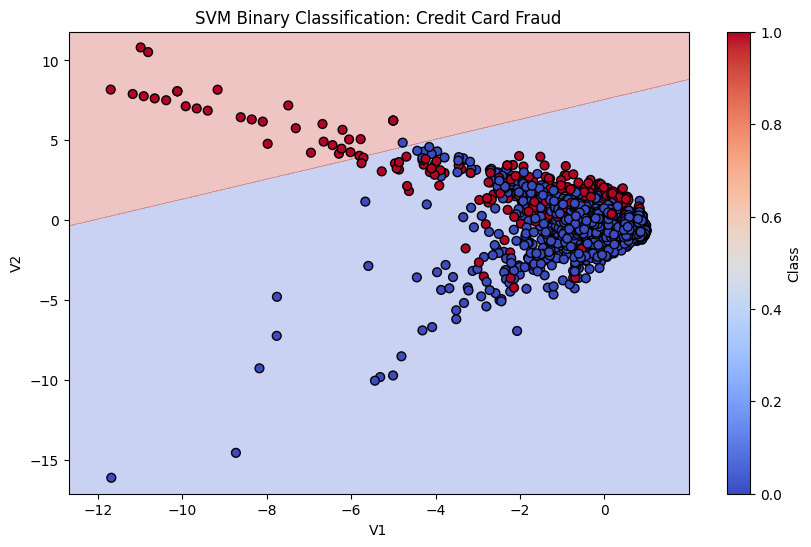


 Number of support vectors: 668


In [ ]:
# Visualize the decision boundary

# Use only 2 features for visualization
X_2d = df_small[['V1', 'V2']]

# Train-test split
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y)

# Scale the 2D data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train a model on 2D data
model =  SVC(kernel='linear', C=1.0)
model.fit(X_train_2d_scaled, y_train_2d)

# Create a mesh grid to plot decision regions
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, .02),
    np.arange(y_min, y_max, .02)
)

# Predict class for each point in the mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Plot training points
plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    edgecolors='k',
    cmap='coolwarm',
    s=40
)

# Set title and labels
plt.xlabel(X_2d.columns[0], fontsize=10)
plt.ylabel(X_2d.columns[1], fontsize=10)
plt.title('SVM Binary Classification: Credit Card Fraud')
plt.colorbar(label='Class')
plt.show()

# Print support vectors
print("\n Number of support vectors:", len(model.support_vectors_))

The Credit Card Fraud Detection dataset was used to build a prediction model to detect whether a credit card transaction is a fraud or not. The model used a Support Vector Machines (SVM) algorithm with the linear kernel. The linear kernel divides the target class regions in a straight line. The dataset contained over 284,807 datapoints with 31 features. Some of the features include amount, time, and from V1 to V29, where V1 to V29 variables are the result of PCA transformation (a process that transforms original variables and creates new ones, reducing dimensionality in a dataset). Additionally, the target class is imbalanced, only about 0.172% transactions (492) are fraud. The model overall showed a 99.14% accuracy, despite this individual class performance indicates it is not as good at catching the concerning fraud transactions. The performance for each individual class, reveals it is better and near perfect in prediction of non fraud outcomes. As for the fraud class, the metrics indicated the model misses a significant amount of cases that are fraud. Based on the recall metric, 82% of fraud cases were correctly identified out of total actual cases for that class. However, it had 100% precision, meaning when a case is predicted fraud, it is 100% fraud. The confusion matrix visualizes what the performance metrics entail. Although it correctly identifies all non-frauds cases, some fraud cases are misidentified as non-fraud. Overall, while the model has strong overall accuracy and F1-score (0.99), it is failing to identify a good proportion of actual fraud cases.
